In [29]:
from plyfile import PlyData, PlyElement
import numpy as np
import os
from pathlib import Path
from argparse import ArgumentParser
import cv2
import matplotlib.pyplot as plt
import open3d as o3d
import json
import random
np.set_printoptions(suppress=True)

In [26]:
def project(xyz, K, RT):
    """
    xyz: [N, 3]
    K: [3, 3]
    RT: [3, 4]
    """
    xyz = np.dot(xyz, RT[:, :3].T) + RT[:, 3:].T
    xyz = np.dot(xyz, K.T)
    xy = xyz[:, :2] / xyz[:, 2:]
    return xy, xyz[:, 2]

In [30]:
root_path = '/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap'
img_dir = os.path.join(root_path, 'images')
img_png_dir = os.path.join(root_path, 'images_png')
mask_dir = os.path.join(root_path, 'mask')
pcd_dir = os.path.join(root_path, 'vertices')
ply_dir = os.path.join(root_path, 'pcds')
cam_inds = sorted(os.listdir(img_dir))
time_inds = [time_ind.split('.')[0] for time_ind in sorted(os.listdir(pcd_dir))]
anno_dir = os.path.join(root_path, 'annots.npy')
anno = np.load(anno_dir, allow_pickle=True).item()

In [9]:
for time_ind in time_inds:
    xyz = np.load(os.path.join(pcd_dir, time_ind + '.npy'))
    centroid = xyz.mean(0)
    rgb = np.zeros_like(xyz)
    depth = np.zeros_like(xyz[:,0]) + 100000000
    for cam_ind in cam_inds:
        img_path = os.path.join(img_dir, cam_ind, time_ind + '.jpg')
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[0], img.shape[1]
        K = np.array(anno['cams']['K'][int(cam_ind)])
        R = np.array(anno['cams']['R'][int(cam_ind)])
        T = np.array(anno['cams']['T'][int(cam_ind)] / 1000.)
        RT = np.concatenate([R, T], axis=1)
        RT = np.concatenate([RT, [[0, 0, 0, 1]]], axis=0)
        R, T = RT[:3, :3], RT[:3, 3:]
        pose = np.concatenate([R, T], axis=1)
        xy, d = project(xyz, K, pose)
        xy_2d = np.round(xy).astype(int)
        rgb_2d = img[xy_2d[:,1]%H, xy_2d[:,0]%W]
        mask = (xy_2d[:,0] >= 0) & (xy_2d[:,0] < W) & (xy_2d[:,1] >= 0) & (xy_2d[:,1] < H) & (d > 0.01) # & (d < depth)
        depth[mask] = d[mask]
        rgb[mask] = rgb_2d[mask]
    dtype = [('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
            ('nx', 'f4'), ('ny', 'f4'), ('nz', 'f4'),
            ('red', 'u1'), ('green', 'u1'), ('blue', 'u1'),
            ('time', 'f4')]
    time = np.zeros_like(xyz[:,0:1]) + int(time_ind) / 30.
    normals = np.zeros_like(xyz)
    elements = np.empty(xyz.shape[0], dtype=dtype)
    attributes = np.concatenate((xyz, normals, rgb, time), axis=1)
    elements[:] = list(map(tuple, attributes))
    vertex_element = PlyElement.describe(elements, 'vertex')

    plydata = PlyData([vertex_element])
    ply_path = os.path.join(ply_dir, time_ind + '.ply')
    plydata.write(ply_path)
    print("Colored point cloud is saved in" + ply_path + "!")

Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000000.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000001.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000002.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000003.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000004.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000005.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000006.ply!
Colored point cloud is saved in/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap/pcds/000007.ply!


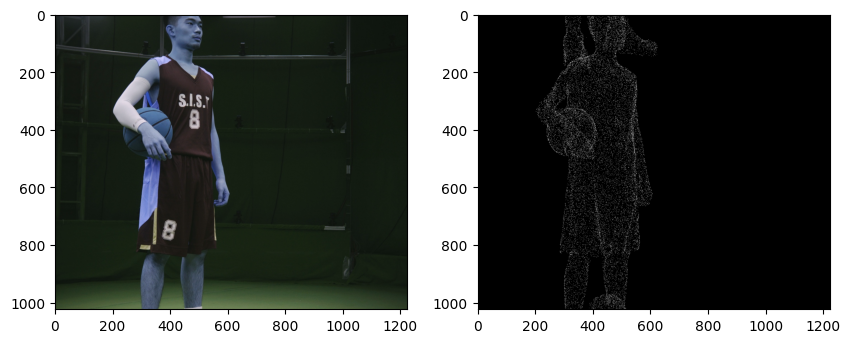

In [155]:
K = np.array(anno['cams']['K'][int(cam_ind)])
R = np.array(anno['cams']['R'][int(cam_ind)])
T = np.array(anno['cams']['T'][int(cam_ind)] / 1000.)
RT = np.concatenate([R, T], axis=1)
RT = np.concatenate([RT, [[0, 0, 0, 1]]], axis=0)
# transform = np.array([[ 0.90630779, -0.07338689,  0.41619774,  2.],
#                [ 0.42261826,  0.1573787 , -0.89253894, -5.13],
#                [ 0.        ,  0.98480775,  0.17364818,  2.85],
#                [ 0.        ,  0.        ,  0.        ,  1.]])
# RT = np.dot(RT, np.linalg.inv(transform))
R, T = RT[:3, :3], RT[:3, 3:]
pose = np.concatenate([R, T], axis=1)

xyz = np.load(os.path.join(pcd_dir, time_ind + '.npy'))
# xyz = np.dot(xyz, transform[:3, :3].T) + transform[:3, 3]

xy = project(xyz, K, pose)
xy_2d = np.round(xy).astype(int)

canvas = np.zeros_like(img).astype(np.uint8)
canvas[xy_2d[:,1] % H, xy_2d[:,0] % W, :] = 255

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(canvas)

In [166]:
np.arctan(2351.929/0.357) / np.pi * 180

89.99130305671258

In [28]:
root_path = '/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/NHR/basketball_easymocap'
img_dir = os.path.join(root_path, 'images')
img_png_dir = os.path.join(root_path, 'images_png')
mask_dir = os.path.join(root_path, 'mask')
pcd_dir = os.path.join(root_path, 'vertices')
ply_dir = os.path.join(root_path, 'pcds')
cam_inds = sorted(os.listdir(img_dir))
time_inds = [time_ind.split('.')[0] for time_ind in sorted(os.listdir(pcd_dir))]
anno_dir = os.path.join(root_path, 'annots.npy')
anno = np.load(anno_dir, allow_pickle=True).item()

frames = []
for cam_ind in cam_inds:
    K = anno['cams']['K'][int(cam_ind)]
    R = np.array(anno['cams']['R'][int(cam_ind)])
    T = np.array(anno['cams']['T'][int(cam_ind)] / 1000.)
    RT = np.concatenate([R, T], axis=1)
    RT = np.concatenate([RT, [[0, 0, 0, 1]]], axis=0)
    c2w = np.linalg.inv(RT)
    c2w[:3, 1:3] *= -1
    fl_x, fl_y, cx, cy = K[0][0], K[1][1], K[0][2], K[1][2]
    for time_ind in time_inds:
        frames.append({
            'file_path': os.path.join("images_png", cam_ind, time_ind),
            'transform_matrix': c2w.tolist(),
            'time': int(time_ind) / 30.,
            'fl_x': fl_x,
            'fl_y': fl_y,
            'cx': cx,
            'cy': cy,
        })

random.shuffle(frames)
out = {
    'frames': frames,
}

out_test = {
    'frames': frames[::15],
}
with open(os.path.join(root_path, 'transforms_train.json'), 'w') as f:
    json.dump(out, f, indent=4)
with open(os.path.join(root_path, 'transforms_test.json'), 'w') as f:
    json.dump(out_test, f, indent=4)

In [222]:
from PIL import Image

In [225]:
for cam_ind in cam_inds:
    print(cam_ind)
    for time_ind in time_inds:
        img_path = os.path.join(img_dir, cam_ind, time_ind + '.jpg')
        mask_path = os.path.join(mask_dir, cam_ind, time_ind + '.jpg')
        img_png_path = os.path.join(img_png_dir, cam_ind, time_ind + '.png')
        image = Image.open(img_path)
        mask = Image.open(mask_path)
        image = np.array(image.convert("RGBA"))
        mask = np.array(mask)
        image[:,:,-1] = mask[:,:,0]
        image = Image.fromarray(image, "RGBA")
        image.save(img_png_path)

0000
0001
0002
0003
0004
0005
0006
0007
0008
0009
0010
0011
0012
0013
0014
0015
0016
0017
0018
0019
0020
0021
0022
0023
0024
0025
0026
0027
0028
0029
0030
0031
0032
0033
0034
0035
0036
0037
0038
0039
0040
0041
0042
0043
0044
0045
0046
0047
0048
0049
0050
0051
0052
0053
0054
0055
0056
0057
0058
0059
0060
0061
0062
0063
0064
0065
0066
0067
0068
0069
0070
0071


In [10]:
def fetchPly(path):
    plydata = PlyData.read(path)
    vertices = plydata['vertex']
    positions = np.vstack([vertices['x'], vertices['y'], vertices['z']]).T
    colors = np.vstack([vertices['red'], vertices['green'], vertices['blue']]).T
    normals = np.vstack([vertices['nx'], vertices['ny'], vertices['nz']]).T
    if 'time' in vertices:
        timestamp = vertices['time'].T
    else:
        timestamp = None
    return positions, colors, normals, timestamp

In [31]:
positions = []
colors = []
normals = []
timestamps = []
for time_ind in time_inds[::5]:
    ply_path = os.path.join(ply_dir, time_ind + '.ply')
    position, color, normal, timestamp = fetchPly(ply_path)
    positions.append(position)
    colors.append(color)
    normals.append(normal)
    timestamps.append(timestamp)

In [32]:
positions = np.concatenate(positions, axis=0)
colors = np.concatenate(colors, axis=0)
normals = np.concatenate(normals, axis=0)
timestamps = np.concatenate(timestamps, axis=0)

In [33]:
dtype = [('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
            ('nx', 'f4'), ('ny', 'f4'), ('nz', 'f4'),
            ('red', 'u1'), ('green', 'u1'), ('blue', 'u1'),
            ('time', 'f4')]
elements = np.empty(positions.shape[0], dtype=dtype)
attributes = np.concatenate((positions, normals, colors, timestamps[:,None]), axis=1)
elements[:] = list(map(tuple, attributes))
vertex_element = PlyElement.describe(elements, 'vertex')

plydata = PlyData([vertex_element])
ply_path = os.path.join(root_path, 'points3d.ply')
plydata.write(ply_path)

In [22]:
timestamps.shape

(267887,)